In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [15]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          0.          0.          0.
  0.          0.         -9.35929044 -8.23056672  0.          0.
  0.          0.          0.          0.          0.         -1.93149689
  0.          0.          0.          0.          0.          0.
  0.          0.         -4.01959343  0.          4.46057556  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          3.62310545  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          2.16801674  0.          0.
  0.         -1.45199639  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  5.18683686  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.  

15.438534611441117

In [16]:
from sklearn.linear_model import Lasso

def preconditioning_lasso_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star):
    """
    Implements the preconditioning LASSO bandit algorithm.

    Args:
        phi (float): Regularization parameter for optimization.
        T (int): Total time steps.
        C_max_wave (float): F_t matrix eigenvalue constraint.
        L (float): Upper limit for X values.
        error_std (float): Standard deviation for error term.
        Y_t (array): Initial response vector.
        X_t (array): Initial feature matrix.
        beta_star (array): True coefficient vector for simulation.

    Returns:
        Y_t, X_t: Updated response vector and feature matrix.
    """
    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        U_t, D_t, V_t_T = np.linalg.svd(X_t, full_matrices=False)
        # Compute F_t using the formula F_t = sqrt(t) * U_t @ D_t_inv @ U_t.T
        F_t = np.sqrt(tau) * U_t @ np.linalg.pinv(np.diag(D_t)) @ U_t.T
        # Compute transformed variables
        Y_t_tran = F_t @ Y_t
        X_t_tran = F_t @ X_t
        

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t_tran, Y_t_tran)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau)


        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max

        
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        #print(f"time {tau}: beta {beta_esti}")
        print(f"time {tau}: reward {Y_max}")
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter


In [17]:
def optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau):
    """
    Perform optimization using a hill-climbing algorithm under given constraints.

    Args:
        beta_esti (numpy array): Estimated coefficients (beta).
        s_esti (float): Estimated parameter for scaling.
        X_t (numpy array): Existing feature matrix.
        lamada (float): Regularization parameter.
        phi (float): Parameter for constraint.
        C_max_wave (float): Constraint for F_t matrix eigenvalue.
        t (int): Time step or scaling factor.
        max_iterations (int): Maximum number of iterations for the algorithm.

    Returns:
        numpy array: Optimized X_max vector.
    """
    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        sqrt_term = np.sqrt(X_max @ np.linalg.pinv((1 / tau) * (X_t.T @ X_t) ) @ X_max.reshape(-1, 1) * (np.sqrt(np.linalg.eigvalsh((1 / tau) * (X_t.T @ X_t)).max())))
        constant = (4 * np.sqrt(s_esti) * lamada / phi)
        return -(beta_esti @ X_max + constant * sqrt_term)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        X_max_optimal = X_max_initial
        print("Optimization failed:", result.message)


    return X_max_optimal


In [18]:
def while_preconditioning_lasso_bandit(beta_star):
    error_std = 1
    phi = 50
    C_max_wave = 1
    t = 2
    T = 1000 + t
    
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T, X_T, Y_t_exp, l_2_error_parameter = preconditioning_lasso_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp, l_2_error_parameter
    

In [19]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_preconditioning_lasso_bandit(beta_star)  # Replace with the actual function
    
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

# The results `cumulative_regre_times` and `l_2_error_parameter_times` now store the outcomes of all experiments.


parameter square error:16.242629236512308
time 2: reward [-5.42774628]
time 2: mean reward -5.102473029436965
parameter square error:16.242629236512308
time 3: reward [-8.71622997]
time 3: mean reward -8.528864479361772
parameter square error:16.242629236512308
time 4: reward [1.11977834]
time 4: mean reward 2.4106505641456524
parameter square error:16.242629236512308
time 5: reward [-10.7190737]
time 5: mean reward -8.999493348817095
parameter square error:16.242629236512308
time 6: reward [-2.54540285]
time 6: mean reward -4.103912753787608
parameter square error:16.242629236512308
time 7: reward [-10.75318888]
time 7: mean reward -11.077521856021399
parameter square error:16.242629236512308
time 8: reward [-0.93754956]
time 8: mean reward -1.5647837798992954
parameter square error:16.242629236512308
time 9: reward [-2.65193198]
time 9: mean reward -3.1923233358275964
parameter square error:16.242629236512308
time 10: reward [-15.23894962]
time 10: mean reward -13.614853765143128
par

In [20]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [  22.00337746   45.88978327   70.45910466 ... 2183.21726494 2183.21726494
 2183.21726494]
Cumulative Regret Std: [ 5.02781125  4.85769034  5.24604456 ... 58.74875434 58.74875434
 58.74875434]
L2 Error Parameter Mean: [1.62426292e+01 1.62426292e+01 1.62426292e+01 1.62426292e+01
 1.62426292e+01 1.62426292e+01 1.62426292e+01 1.62426292e+01
 1.62426292e+01 1.62426292e+01 1.62426292e+01 1.62426292e+01
 1.61318977e+01 1.59363443e+01 1.56219634e+01 1.54301095e+01
 1.51771944e+01 1.46072799e+01 1.46839178e+01 1.47398744e+01
 1.78226551e+01 2.18090723e+01 3.38217729e+01 5.42054908e+01
 8.55062784e+01 1.55580958e+02 2.52647798e+02 4.31246419e+02
 7.52315496e+02 1.29180254e+03 2.20298564e+03 3.86551395e+03
 6.70234896e+03 1.35447111e+04 2.58499004e+04 5.08167153e+04
 9.33641891e+04 1.91786905e+05 3.59239097e+05 6.98242129e+05
 1.15303539e+06 1.49408915e+06 2.03849639e+06 2.72699834e+06
 3.55404668e+06 4.70390916e+06 6.11576463e+06 7.98770959e+06
 9.98838847e+06 1.34165044

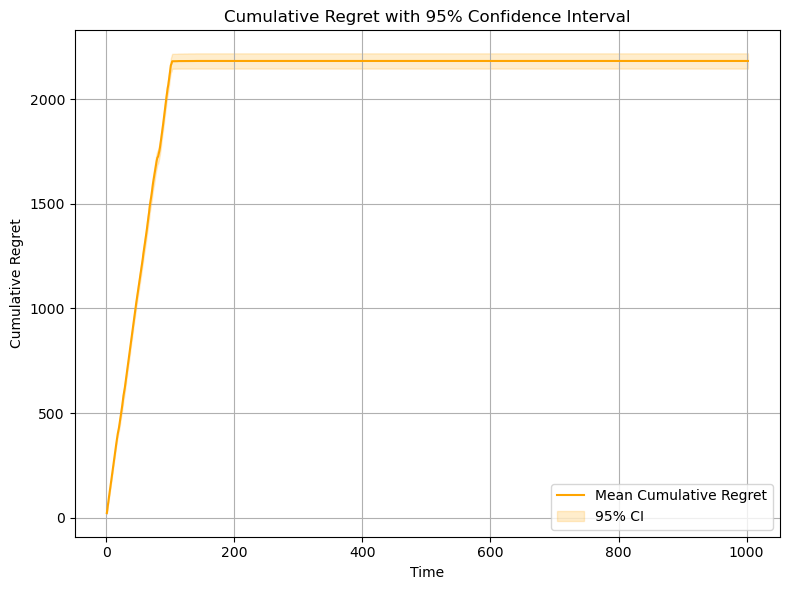

In [21]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [22]:
np.save('cumulative_regret_pre-lasso-stochastic-bandit-d100-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_pre-lasso-stochastic-bandit-d100-s10_10times.npy', l_2_error_parameter_times)